In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import genextreme as gev

from unseen import eva
from unseen import stability

import utils

In [2]:
# optional parameters
# (this cell is tagged "parameters")

metric = 'txx'
location = 'Surat'
model_dict = {
    'BCC-CSM2-MR': 'tab:blue',
#    'CAFE': 'tab:orange',
    'CMCC-CM2-SR5': 'tab:green',
#    'CanESM5': 'tab:red',
    'EC-Earth3': 'tab:purple',
    'IPSL-CM6A-LR': 'tab:brown',
#    'MIROC6': 'tab:pink',
    'MPI-ESM1-2-HR': 'tab:grey',
    'MRI-ESM2-0': 'tab:olive',
    'NorCPM1': 'tab:cyan',
}  

In [3]:
assert "location" in locals(), "Must provide a location name"
assert "metric" in locals(), "Must provide a metric (rx1day or txx)"
assert "model_dict" in locals(), "Must provide a model dict"

## Analysis

In [4]:
def get_gev_uncertainty(da_model, reference_return_values, name):
    """Get GEV uncertainty."""

    bootstrap_samples_dict = {}
    rng = np.random.default_rng(seed=0)
    n_bootstraps = 100
    for i in range(n_bootstraps):
        boot_data = rng.choice(da_model.values, size=da_model.shape, replace=True)
        gev_params = list(eva.fit_gev(boot_data))
        return_periods, return_values = stability.return_curve(boot_data, 'gev', params=gev_params)
        diff = return_values - reference_return_values
        bootstrap_samples_dict[i] = np.abs(diff)
    df = pd.DataFrame(bootstrap_samples_dict)
    df.index = return_periods
#    df = df.drop([1.0])
    ds = df.var(axis=1)
    ds.name = name

    return ds
    

def get_return_values(metric, location, model_dict):
    """Get return values for each dataset."""
    
    return_values_dict = {}
    gev_spread_dict = {}

    da_obs = utils.get_obs_data(metric, location)
    da_obs_detrended, linear_data_obs = utils.detrend_obs(da_obs)
    gev_shape_obs_detrended, gev_loc_obs_detrended, gev_scale_obs_detrended = eva.fit_gev(da_obs_detrended.values)
    return_periods, return_values_obs = stability.return_curve(
        da_obs_detrended,
        'gev',
        params=[gev_shape_obs_detrended, gev_loc_obs_detrended, gev_scale_obs_detrended],
    )
    return_values_dict[('obs', 'AGCD')] = return_values_obs
    gev_spread_obs = get_gev_uncertainty(
        da_obs_detrended,
        return_values_obs,
        name=('obs', 'AGCD'),
    )
    gev_spread_dict[('obs', 'AGCD')] = gev_spread_obs

    for model in model_dict:
        print(model)
        da_model_stacked = utils.get_model_data(metric, model, location)
        da_model_detrended, da_model_detrended_stacked, linear_data_model = utils.detrend_model(da_model_stacked)
        da_model_detrended_stacked_bc_mean = utils.mean_correction(da_model_detrended, da_obs_detrended, metric)
        da_model_detrended_stacked_bc_quantile = utils.quantile_correction(da_model_detrended_stacked, da_obs_detrended, metric)
        gev_model_detrended = list(eva.fit_gev(da_model_detrended_stacked.values))
        gev_model_detrended_bc_mean = list(eva.fit_gev(da_model_detrended_stacked_bc_mean.values))
        gev_model_detrended_bc_quantile = list(eva.fit_gev(da_model_detrended_stacked_bc_quantile.values))
        return_periods, return_values_model_raw = stability.return_curve(
            da_model_detrended_stacked,
            'gev',
            params=gev_model_detrended,
        )
        gev_spread_model_raw = get_gev_uncertainty(
            da_model_detrended_stacked,
            return_values_model_raw,
            name=('model-raw', model),
        )
        return_periods, return_values_model_bc_mean = stability.return_curve(
            da_model_detrended_stacked_bc_mean,
            'gev',
            params=gev_model_detrended_bc_mean,
        )
        gev_spread_model_bc_mean = get_gev_uncertainty(
            da_model_detrended_stacked_bc_mean,
            return_values_model_bc_mean,
            name=('model-bc-mean', model),
        )
        return_periods, return_values_model_bc_quantile = stability.return_curve(
            da_model_detrended_stacked_bc_quantile,
            'gev',
            params=gev_model_detrended_bc_quantile,
        )
        gev_spread_model_bc_quantile = get_gev_uncertainty(
            da_model_detrended_stacked_bc_quantile,
            return_values_model_bc_quantile,
            name=('model-bc-quantile', model),
        )
        return_values_dict[('model-raw', model)] = return_values_model_raw
        return_values_dict[('model-bc-mean', model)] = return_values_model_bc_mean
        return_values_dict[('model-bc-quantile', model)] = return_values_model_bc_quantile
        gev_spread_dict[('model-raw', model)] = gev_spread_model_raw
        gev_spread_dict[('model-bc-mean', model)] = gev_spread_model_bc_mean
        gev_spread_dict[('model-bc-quantile', model)] = gev_spread_model_bc_quantile

    return_values_df = pd.DataFrame(return_values_dict)
    return_values_df.index = return_periods
    return_values_df = return_values_df.drop([1.0])
    gev_spread_df = pd.DataFrame(gev_spread_dict)
    gev_spread_df.index = return_periods
    gev_spread_df = gev_spread_df.drop([1.0])
    
    return return_values_df, gev_spread_df

In [5]:
def plot_return_curves(
    metric,
    curve_list,
    model_dict,
    return_df,
    ylim=[],
    legend_offset=1.5,
    outfile=None,
):
    """Plot return curves.
    
    The curve list can include:
    - 'obs': observations
    - 'model-raw': raw model data
    - 'model-bc-mean': mean bias corrected model data
    - 'model-bc-quantile': quantile bias corrected model data
    
    """

    bias_method = 'multiplicative' if metric == 'rx1day' else 'additive'
    return_periods = return_df.index.values
    
    fig = plt.figure(figsize=[7, 6])
    ax = fig.add_subplot(111)
    for model, color in model_dict.items():
        if 'model-raw' in curve_list:
            ax.plot(
                return_periods,
                return_df[('model-raw', model)].values,
                label=f'{model} (raw)',
                color=color
            )
        if 'model-bc-mean' in curve_list:
            ax.plot(
                return_periods,
                return_df[('model-bc-mean', model)].values,
                label=f'{model} (mean correction, {bias_method})',
                color=color,
                linestyle=':',
            )
        if 'model-bc-quantile' in curve_list:
            ax.plot(
                return_periods,
                return_df[('model-bc-quantile', model)].values,
                label=f'{model} (quantile correction, {bias_method})',
                color=color,
                linestyle='--',
            )

    if 'obs' in curve_list:
        ax.plot(
            return_periods,
            return_df[('obs', 'AGCD')].values,
            label='AGCD',
            color='lime',
            linewidth=2.0
        )

    if 'model-raw' in curve_list:
        ave_model_raw = return_df.filter(like='model-raw').mean(axis=1)
        ax.plot(
            return_periods,
            ave_model_raw.values,
            label=f'multi-model mean (raw)',
            color='black',
            linewidth=2.0,
        )
    if 'model-bc-mean' in curve_list:
        ave_model_bc_mean = return_df.filter(like='model-bc-mean').mean(axis=1)
        ax.plot(
            return_periods,
            ave_model_bc_mean.values,
            label=f'multi-model mean (mean correction)',
            color='black',
            linestyle=':',
            linewidth=2.0,
        )
    if 'model-bc-quantile' in curve_list:
        ave_model_bc_quantile = return_df.filter(like='model-bc-quantile').mean(axis=1)
        ax.plot(
            return_periods,
            ave_model_bc_quantile.values,
            label=f'multi-model mean (quantile correction)',
            color='black',
            linestyle='--',
            linewidth=2.0,
        )
    
    ax.legend(bbox_to_anchor=(legend_offset, 0.5), loc='center right')
    ax.set_xscale('log')
    ax.set_xlabel('return period (years)')
    ax.set_ylabel(f'{metric}')
    ax.set_title('Return periods corresponding to GEV fits')
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(which='both')
    if outfile:
        plt.savefig(outfile, bbox_inches='tight', facecolor='white')
    plt.show()

In [6]:
def plot_uncertainty(
    metric,
    return_df,
    gev_spread_df,
    ylim=[],
    outfile=None,
):
    """Plot uncertainty."""
    
    gev_spread = gev_spread_df.filter(like='model-bc-mean').mean(axis=1)
    G2 = gev_spread
    G = np.sqrt(G2)

    model_bc_mean_spread = return_df.filter(like='model-bc-mean').var(axis=1)
    M2 = model_bc_mean_spread
    M = np.sqrt(M2)
    
    B2_models = []
    for bias_method, model in return_df.filter(like='model-bc-mean').columns.values:
        B2 = return_df[[('model-bc-mean', model), ('model-bc-quantile', model)]].var(axis=1)
        B2.name = model
        B2_models.append(B2)
    B2_ensemble = pd.concat(B2_models, axis=1)
    bias_spread = B2_ensemble.mean(axis=1)
    B2 = bias_spread
    B = np.sqrt(B2)

    T2 = G2 + M2 + B2
    T = np.sqrt(T2)
    F = (G + M + B) / T

    ave_model_bc_mean = return_df.filter(like='model-bc-mean').mean(axis=1)
    gev_spread_upper = ave_model_bc_mean + (G / F)
    gev_spread_lower = ave_model_bc_mean - (G / F) 
    model_spread_upper = ave_model_bc_mean + ((G + M) / F)
    model_spread_lower = ave_model_bc_mean - ((G + M) / F)
    bias_spread_upper = ave_model_bc_mean + ((G + M + B) / F)
    bias_spread_lower = ave_model_bc_mean - ((G + M + B) / F)

    obs = return_df[('obs', 'AGCD')]
    gev_spread_obs = np.sqrt(gev_spread_df[('obs', 'AGCD')])
    gev_spread_obs_upper = obs + gev_spread_obs
    gev_spread_obs_lower = obs - gev_spread_obs
    
    return_periods = return_df.index.values
    fig = plt.figure(figsize=[7, 6])
    ax = fig.add_subplot(111)

    count = 0
    for model in return_df.filter(like='model-bc-mean').columns.values:
        data = return_df[model].values
        if count == 0:
            ax.plot(return_periods, data, label='individual models (mean correction)', color='tab:blue', linewidth=0.7)
        else:
            ax.plot(return_periods, data, color='tab:blue', linewidth=0.7)
        count = count + 1
    
    ax.plot(return_periods, obs.values, label='observations', color='tab:red')
#    ax.fill_between(return_periods, obs.values, gev_spread_obs_upper.values, label='GEV uncertainty (obs)', color='tab:red', alpha=0.3)
#    ax.fill_between(return_periods, gev_spread_obs_lower.values, obs.values, color='tab:red', alpha=0.3)
    ax.plot(return_periods, gev_spread_obs_upper.values, label='uncertainty bounds (obs)', color='tab:red', linestyle=':')
    ax.plot(return_periods, gev_spread_obs_lower.values, color='tab:red', linestyle=':')
    
    ax.plot(return_periods, ave_model_bc_mean.values, label='multi-model mean (mean correction)', color='black')
    ax.plot(return_periods, bias_spread_upper.values, label='uncertainty bounds (model)', color='black', linestyle=':')
    ax.plot(return_periods, bias_spread_lower.values, color='black', linestyle=':')
    
    ax.fill_between(return_periods, ave_model_bc_mean.values, gev_spread_upper.values, label='GEV uncertainty', color='tab:orange', alpha=0.3)
    ax.fill_between(return_periods, gev_spread_lower.values, ave_model_bc_mean.values, color='tab:orange', alpha=0.3)
    ax.fill_between(return_periods, gev_spread_upper.values, model_spread_upper.values, label='model uncertainty', color='tab:blue', alpha=0.3)
    ax.fill_between(return_periods, model_spread_lower.values, gev_spread_lower.values, color='tab:blue', alpha=0.3)
    ax.fill_between(return_periods, model_spread_upper.values, bias_spread_upper.values, label='bias correction uncertainty', color='tab:green', alpha=0.3)
    ax.fill_between(return_periods, bias_spread_lower.values, model_spread_lower.values, color='tab:green', alpha=0.3)

    ax.legend(fontsize='small')
    ax.set_xscale('log')
    ax.set_xlabel('return period (years)')
    ax.set_ylabel(f'{metric}')
    ax.set_title('Return periods corresponding to GEV fits - ensemble')
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(which='both')

    if outfile:
        plt.savefig(outfile, bbox_inches='tight', facecolor='white')
    plt.show()

In [7]:
def plot_uncertainty_1model(
    metric,
    return_df,
    gev_spread_df,
    model,
    ylim=[],
    outfile=None,
):
    """Plot uncertainty."""

    gev_spread = gev_spread_df[('model-bc-mean', model)]
    G2 = gev_spread
    G = np.sqrt(G2)
    
    B2 = return_df[[('model-bc-mean', model), ('model-bc-quantile', model)]].var(axis=1)
    B = np.sqrt(B2)

    T2 = G2 + B2
    T = np.sqrt(T2)
    F = (G + B) / T

    model_bc_mean = return_df[('model-bc-mean', model)]
    model_bc_quantile = return_df[('model-bc-quantile', model)]
    gev_spread_upper = model_bc_mean + (G / F)
    gev_spread_lower = model_bc_mean - (G / F) 
    bias_spread_upper = model_bc_mean + ((G + B) / F)
    bias_spread_lower = model_bc_mean - ((G + B) / F)

    obs = return_df[('obs', 'AGCD')]
    gev_spread_obs = np.sqrt(gev_spread_df[('obs', 'AGCD')])
    gev_spread_obs_upper = obs + gev_spread_obs
    gev_spread_obs_lower = obs - gev_spread_obs
    
    return_periods = return_df.index.values
    fig = plt.figure(figsize=[7, 6])
    ax = fig.add_subplot(111)
    
    ax.plot(return_periods, obs.values, label='observations', color='tab:red')
    ax.plot(return_periods, gev_spread_obs_upper.values, label='uncertainty bounds (obs)', color='tab:red', linestyle=':')
    ax.plot(return_periods, gev_spread_obs_lower.values, color='tab:red', linestyle=':')
    
    ax.plot(return_periods, model_bc_mean.values, label='model (mean correction)', color='tab:blue')
    ax.plot(return_periods, bias_spread_upper.values, label='uncertainty bounds (model)', color='tab:blue', linestyle=':')
    ax.plot(return_periods, bias_spread_lower.values, color='tab:blue', linestyle=':')

    ax.plot(return_periods, model_bc_quantile.values, label='model (quantile correction)', color='tab:green')
    
    ax.fill_between(return_periods, model_bc_mean.values, gev_spread_upper.values, label='GEV uncertainty', color='tab:orange', alpha=0.3)
    ax.fill_between(return_periods, gev_spread_lower.values, model_bc_mean.values, color='tab:orange', alpha=0.3)
    ax.fill_between(return_periods, gev_spread_upper.values, bias_spread_upper.values, label='bias correction uncertainty', color='tab:green', alpha=0.3)
    ax.fill_between(return_periods, bias_spread_lower.values, gev_spread_lower.values, color='tab:green', alpha=0.3)

    ax.legend(fontsize='small')
    ax.set_xscale('log')
    ax.set_xlabel('return period (years)')
    ax.set_ylabel(f'{metric}')
    ax.set_title(f'Return periods corresponding to GEV fits - {model}')
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(which='both')

    if outfile:
        plt.savefig(outfile, bbox_inches='tight', facecolor='white')
    plt.show()

## Plots

In [8]:
return_df, gev_spread_df = get_return_values(metric, location, model_dict)

BCC-CSM2-MR
CMCC-CM2-SR5
EC-Earth3
IPSL-CM6A-LR
MPI-ESM1-2-HR
MRI-ESM2-0
NorCPM1


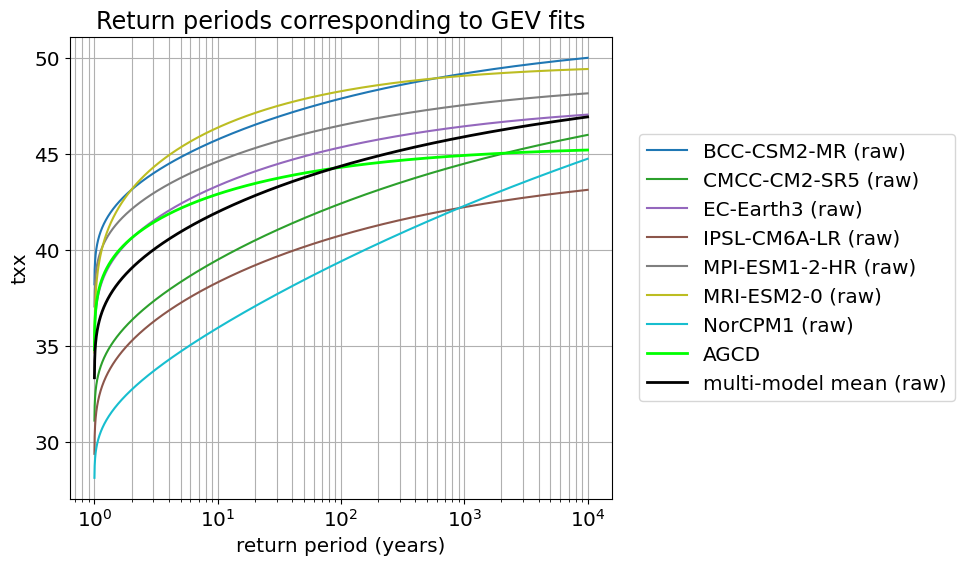

In [10]:
plot_return_curves(
    metric,
    ['model-raw', 'obs'],
    model_dict,
    return_df,
#    ylim=[35, 48],
    legend_offset=1.65,
)

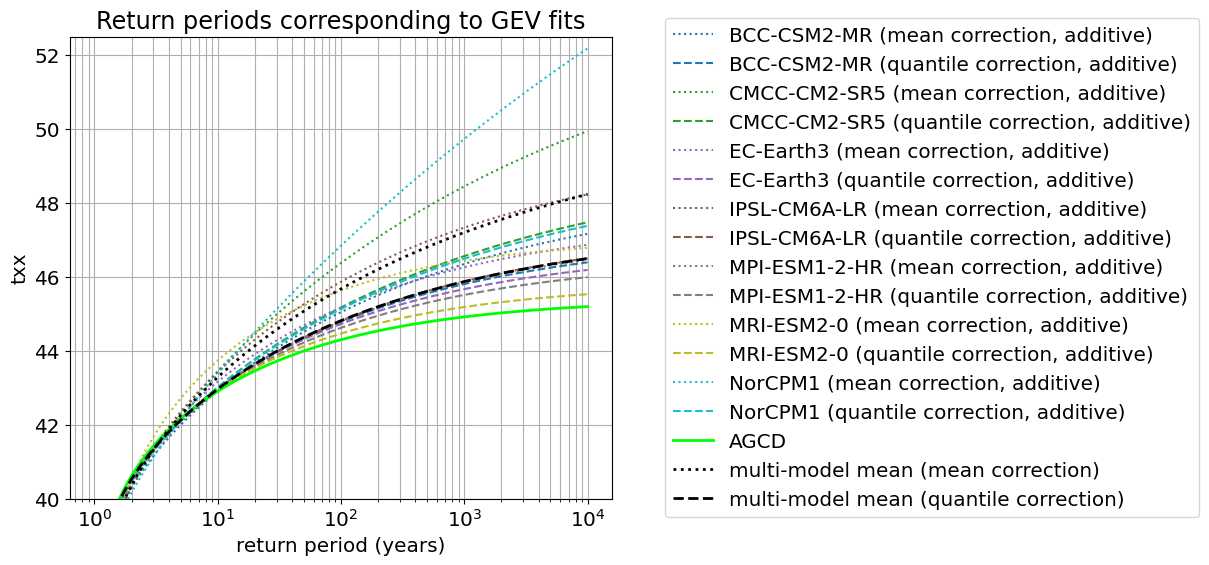

In [13]:
plot_return_curves(
    metric,
    ['model-bc-mean', 'model-bc-quantile', 'obs'],
    model_dict,
    return_df,
    ylim=[40, 52.5],
    legend_offset=2.1,
)

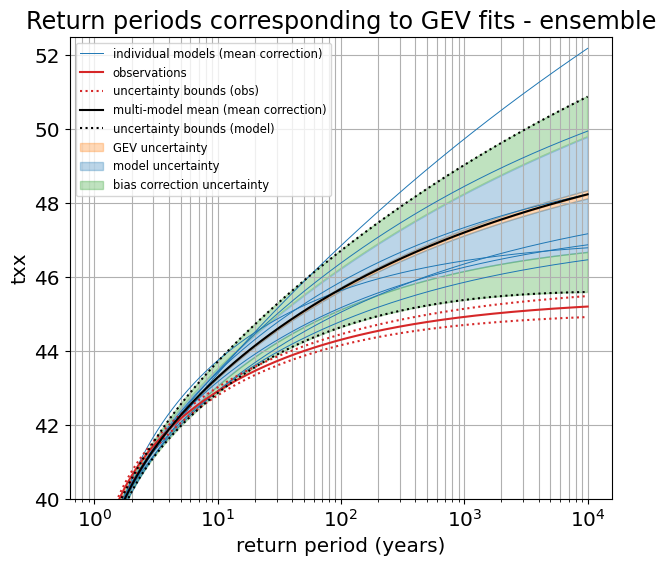

In [14]:
plot_uncertainty(
    metric,
    return_df,
    gev_spread_df,
    ylim=[40, 52.5]
)

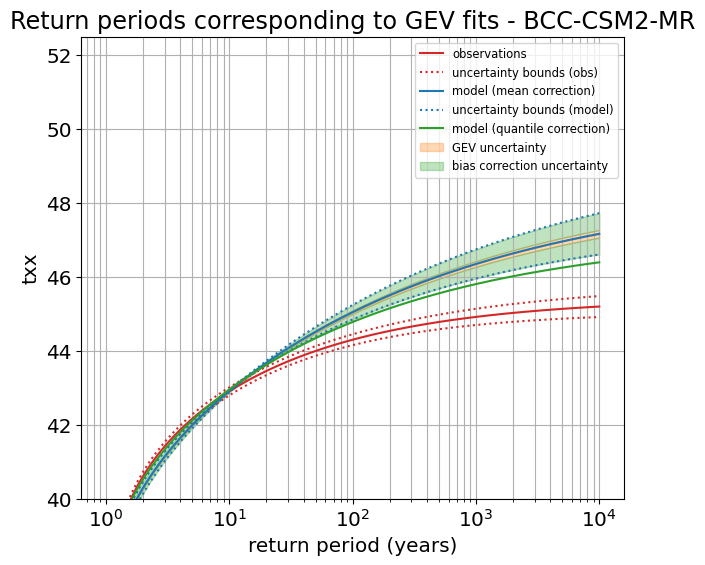

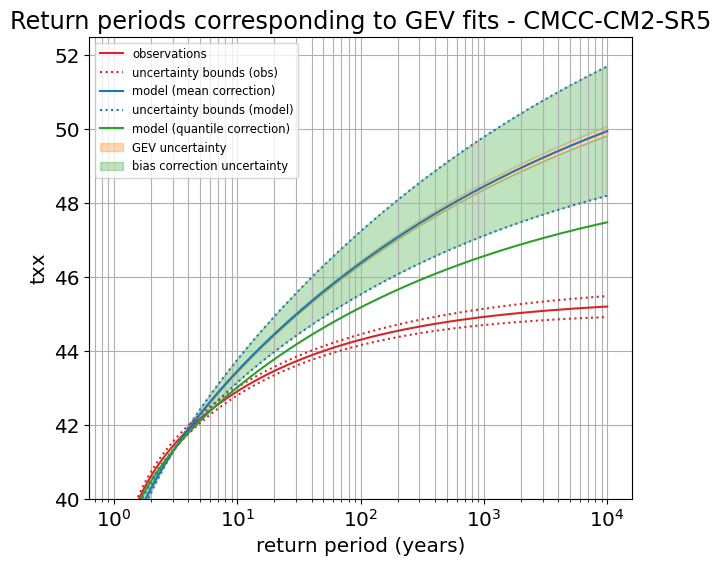

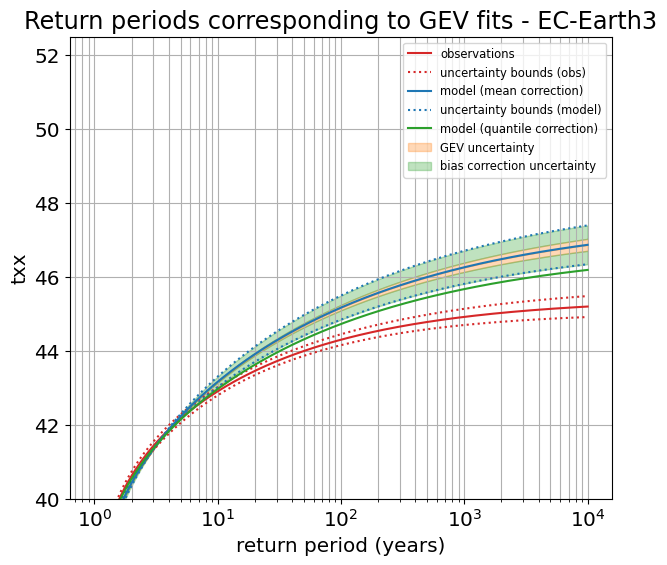

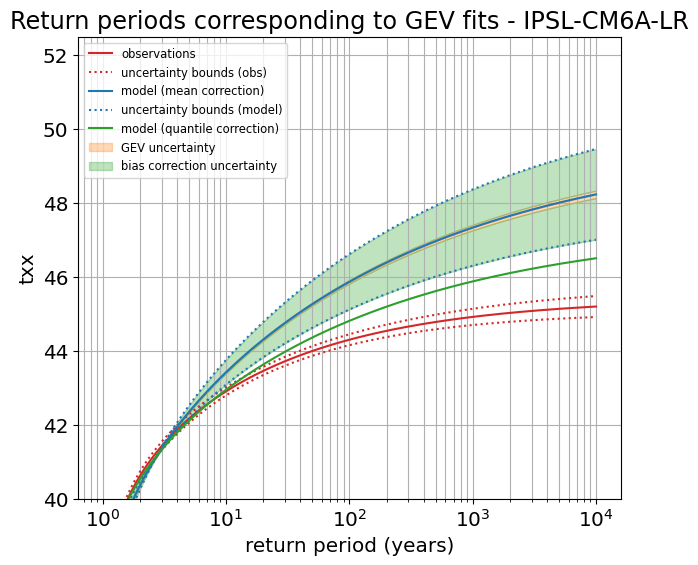

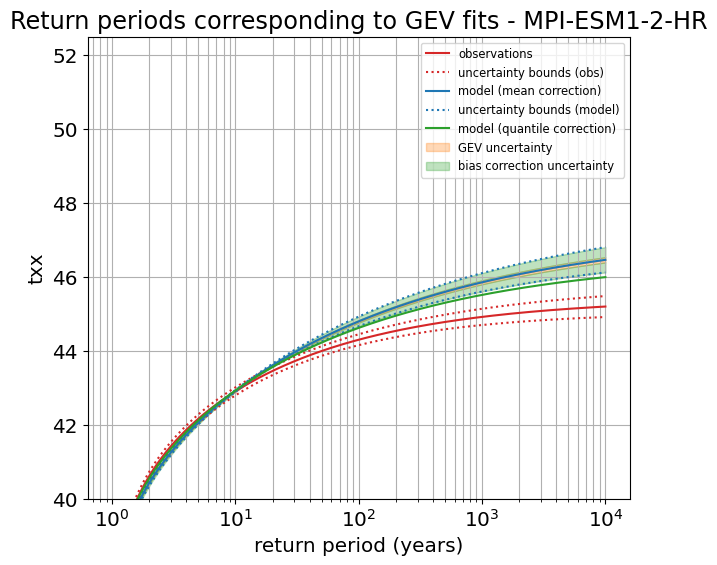

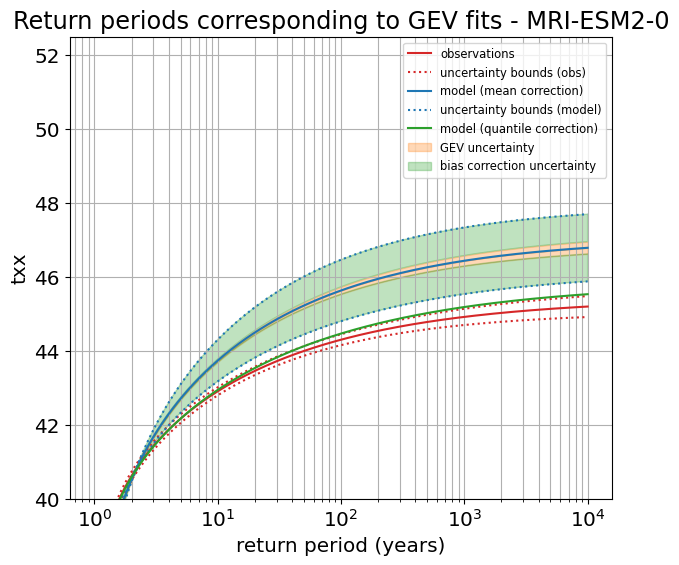

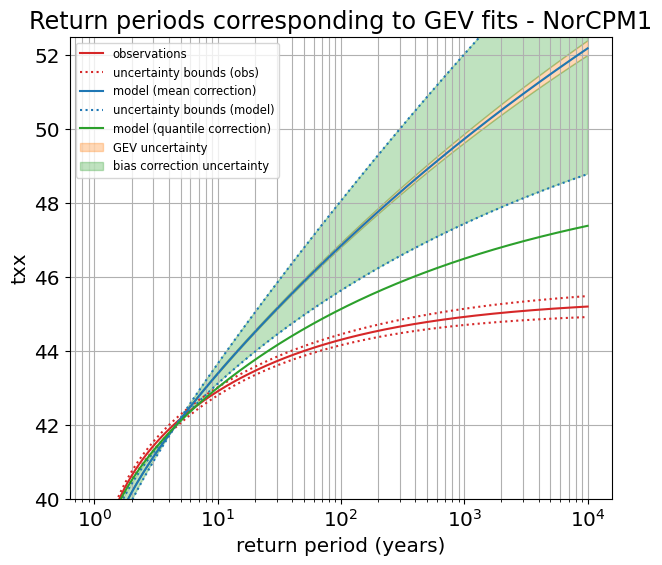

In [15]:
for bias_method, model in return_df.filter(like='model-bc-mean').columns.values:
    plot_uncertainty_1model(
        metric,
        return_df,
        gev_spread_df,
        model,
        ylim=[40, 52.5]
    )